In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

file = "./dataset/Income3.csv"
data = np.genfromtxt(file,dtype=None, names=True, delimiter=",", encoding = None)
print(data.shape)
print(data.dtype)
print(data[:10])

(20,)
[('Observation', '<i4'), ('Years_of_Higher_Education_x', '<i4'), ('Income_y', '<i4')]
[( 1, 6, 89617) ( 2, 0, 39826) ( 3, 6, 79894) ( 4, 3, 56547)
 ( 5, 4, 64795) ( 6, 0, 31007) ( 7, 5, 76229) ( 8, 6, 81044)
 ( 9, 0, 39467) (10, 6, 83546)]


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

file = "./dataset/Income3.csv"
data = np.genfromtxt(file,dtype=None, names=True, delimiter=",", encoding = None)
print(data.shape)
print(data.dtype)
print(data[:10])

(20,)
[('Observation', '<i4'), ('Years_of_Higher_Education_x', '<i4'), ('Income_y', '<i4')]
[( 1, 6, 89617) ( 2, 0, 39826) ( 3, 6, 79894) ( 4, 3, 56547)
 ( 5, 4, 64795) ( 6, 0, 31007) ( 7, 5, 76229) ( 8, 6, 81044)
 ( 9, 0, 39467) (10, 6, 83546)]


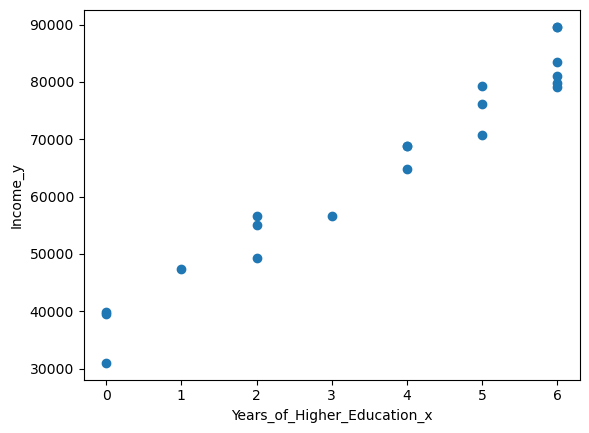

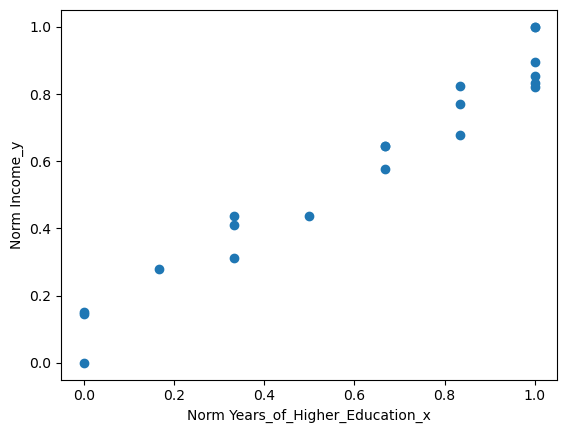

In [11]:
X = data[data.dtype.names[1]]
Y = data[data.dtype.names[2]]

plt.scatter(X,Y)
plt.ylabel(data.dtype.names[2])
plt.xlabel(data.dtype.names[1])
plt.show()

normX = (X - X.min(0)) / X.ptp(0)
normY = (Y - Y.min(0)) / Y.ptp(0)

plt.scatter(normX,normY)
plt.ylabel("Norm " + data.dtype.names[2])
plt.xlabel("Norm " + data.dtype.names[1])
plt.show()

a - 0.7147201151839904 
b - 0.15562350762122823


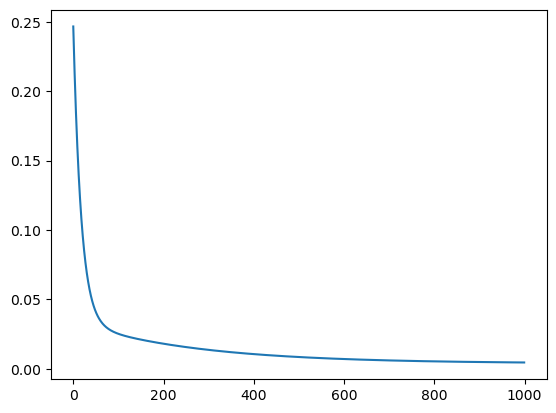

In [13]:
# Building the model.
# calculate predicted value, cost and change.
# X and Y are original data and label.

def forward(a, b, X, Y):
       
    m = X.shape[0] # Number of elements in X
    Y_pred, cost, D_a, D_b = 0,0,0,0
    
    ## Uncomment the following lines and fill in with your answer   
    ## The predicted value of Y
    
    Y_pred = a * X + b
    
    ## Calculate the cost
    
    cost = (1/m) * np.sum(np.square((Y_pred - Y)))
    
    ## Calculate Derivative a, b
    D_a = (2 / m) * np.sum((Y_pred - Y) * X)
    D_b = (2 / m) * np.sum(Y_pred - Y)    
    
    return {
        "Y_pred" : Y_pred,
        "cost" : cost,
        "D_a" : D_a,
        "D_b" : D_b
    }

def gradient( X, Y, learning_rate = 0.001, epoch = 50000):
    a = 0.1
    b = 0.1
    
    cost = np.zeros(epoch)
    
    for i in range(epoch): 
        parameters = {}
        
        ## Uncomment the following line and fill in wiht your answer
        
        parameters = forward(a, b, X, Y)
        a = a - learning_rate * parameters["D_a"]  # Update a
        b = b - learning_rate * parameters["D_b"]  # Update b
        cost[i] = parameters["cost"]
        
    return a, b, cost

# 4. plot the cost vs epochs (number of iterations)
# Performing Gradient Descent / Training model

learning_rate = 0.01  # The learning Rate
epoch = 1000  # The number of iterations to perform gradient descent
a, b, cost = gradient(normX, normY, learning_rate, epoch)
print ("a - " + str(a), "\nb - " + str(b))
plt.plot(cost)
plt.show()

0.15562350762122823 0.8703436228052186
0.0 1.0


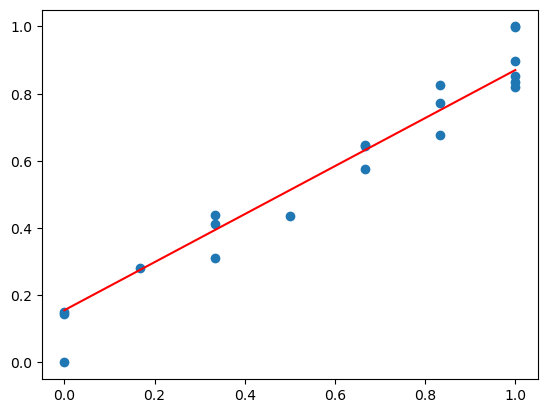

In [15]:
Y_pred_min = a*min(normX) + b
Y_pred_max = a*max(normX) + b

print(Y_pred_min , Y_pred_max)
print(min(normX), max(normX))
plt.scatter(normX, normY) 
plt.plot([min(normX), max(normX)], [Y_pred_min, Y_pred_max], color='red')  # regression line
plt.show()

40128.09378168019 82017.83973261385


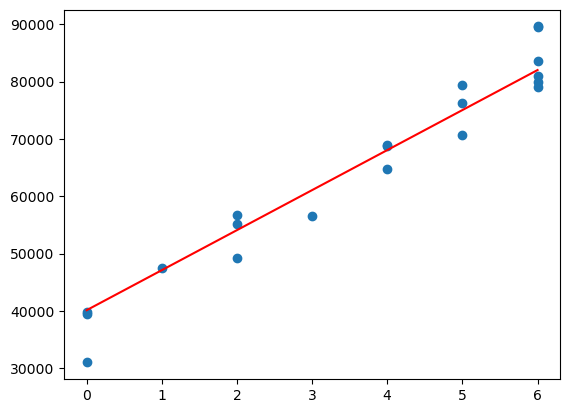

In [17]:
Y_pred_min = Y_pred_min*Y.ptp(0) + Y.min()
Y_pred_max = Y_pred_max*Y.ptp(0) + Y.min()

print(Y_pred_min , Y_pred_max)
plt.scatter(X, Y) 
plt.plot([min(X), max(X)], [Y_pred_min, Y_pred_max], color='red')  # regression line
plt.show()

In [19]:
# 1) R-squared and Adjusted R-squared function 

def r_squared(Y, Y_pred, num_feature):
    
    ss_err, ss_tot, r2, adjusted_r2 = 0,0,0,0
    
    ## Calculate sum squares residual errors and sum squares total
    
    ss_err = np.sum(np.square((Y_pred - Y)))

    ss_tot = np.sum(np.square((Y - np.mean(Y))))
    
    ## Calculate R-square and Adjusted R-square
    
    r2 = 1 - (ss_err/ss_tot)

    adjusted_r2 = 1 - ( ((1-r2) * (len(Y)-1)) / (len(Y)-num_feature-1) )
    
    return r2, adjusted_r2

Y_pred = a * normX + b
r2, adjusted_r2 = r_squared(normY, Y_pred, 1)

print (r2)
print (adjusted_r2)

0.9457699888541073
0.9427572104571134


In [21]:
a, b, cost = gradient(X, Y, learning_rate, epoch)

print ("a - " + str(a), "\nb - " + str(b))
Y_pred = a * X + b
#params = forward(a, b, X, Y)
display = pd.DataFrame()
display['Original']=Y
display['Predicted']=Y_pred #params['Y_pred']
print(display)

a - 7738.283872313206 
b - 37043.63924056803
    Original     Predicted
0      89617  83473.342474
1      39826  37043.639241
2      79894  83473.342474
3      56547  60258.490858
4      64795  67996.774730
5      31007  37043.639241
6      76229  75735.058602
7      81044  83473.342474
8      39467  37043.639241
9      83546  83473.342474
10     68852  67996.774730
11     79357  75735.058602
12     68901  67996.774730
13     49198  52520.206985
14     47407  44781.923113
15     89594  83473.342474
16     56696  52520.206985
17     55078  52520.206985
18     70756  75735.058602
19     79069  83473.342474


a - 0.7875370424239243 
b - 0.10677062212005925


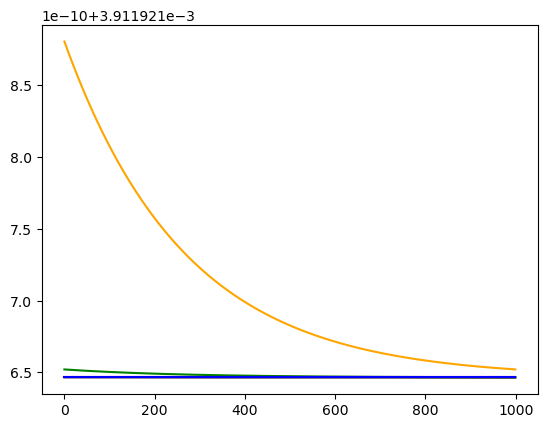

In [23]:
learning_rate = 0.01
epoch = 10000


#2) Call gradient function to calculate and display a, b and cost

a, b, cost = gradient(normX, normY, learning_rate, epoch)

print ("a - " + str(a), "\nb - " + str(b))

#3) Plot different range of cost data

plt.plot(cost[5000:6000], color='orange')
plt.plot(cost[6000:7000], color='green')
plt.plot(cost[7000:8000], color='black')
plt.plot(cost[8000:9000], color='red')
plt.plot(cost[9000:10000], color='blue')
plt.show()

In [25]:
import matplotlib.pyplot as plt
import numpy as np

##1. Read and load data from auto-mpg.data.csv


file = "dataset/auto-mpg-clean.csv"

data = np.genfromtxt(file, dtype=None, names=True, delimiter=",", encoding = None)

print(data.shape)
print(data.dtype)
print(data[:10])

(392,)
[('mpg', '<f8'), ('cylinders', '<i4'), ('displacement', '<f8'), ('horsepower', '<i4'), ('weight', '<i4'), ('acceleration', '<f8'), ('model_year', '<i4'), ('origin', '<i4'), ('car_name', '<U36')]
[(26. , 4, 97., 46, 1835, 20.5, 70, 2, 'volkswagen 1131 deluxe sedan')
 (26. , 4, 97., 46, 1950, 21. , 73, 2, 'volkswagen super beetle')
 (43.1, 4, 90., 48, 1985, 21.5, 78, 2, 'volkswagen rabbit custom diesel')
 (44.3, 4, 90., 48, 2085, 21.7, 80, 2, 'vw rabbit c (diesel)')
 (43.4, 4, 90., 48, 2335, 23.7, 80, 2, 'vw dasher (diesel)')
 (29. , 4, 68., 49, 1867, 19.5, 73, 2, 'fiat 128')
 (31. , 4, 76., 52, 1649, 16.5, 74, 3, 'toyota corona')
 (29. , 4, 85., 52, 2035, 22.2, 76, 1, 'chevrolet chevette')
 (32.8, 4, 78., 52, 1985, 19.4, 78, 3, 'mazda glc deluxe')
 (44. , 4, 97., 52, 2130, 24.6, 82, 2, 'vw pickup')]


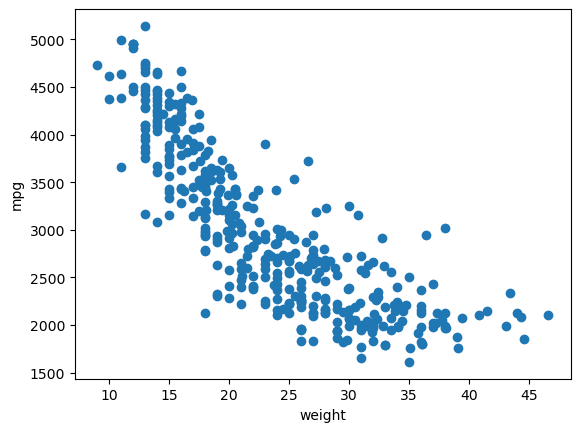

In [27]:
X = data[data.dtype.names[0]]

Y = data[data.dtype.names[4]]

##2. Plot scatter diagram with MPG and Weight

plt.scatter(X, Y)

plt.ylabel("mpg")
plt.xlabel("weight")
plt.show()

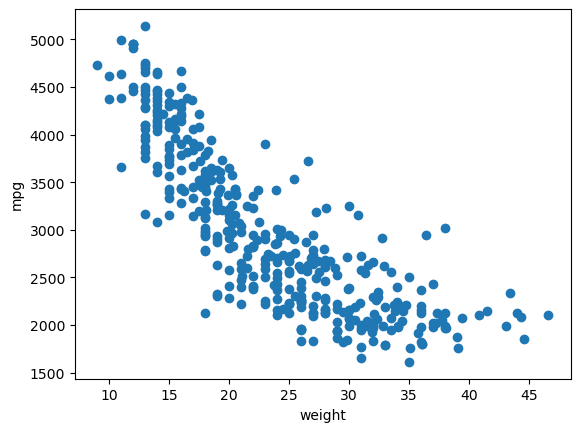

In [29]:
X = data[data.dtype.names[0]]

Y = data[data.dtype.names[4]]

##2. Plot scatter diagram with MPG and Weight

plt.scatter(X, Y)

plt.ylabel("mpg")
plt.xlabel("weight")
plt.show()

a - 0.7875370460981493 
b - 0.10677061965502013


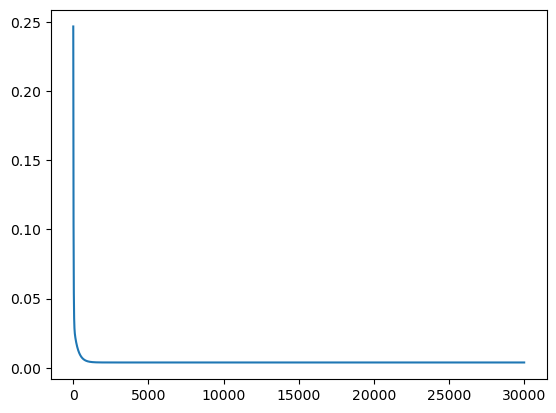

In [31]:
learning_rate = 0.01  # The learning Rate
epoch = 30000  # The number of iterations to perform gradient descent
a, b, cost = gradient(normX, normY, learning_rate, epoch)
print ("a - " + str(a), "\nb - " + str(b))
plt.plot(cost)
plt.show()